In [1]:
import torch
print("CUDA Available:", torch.cuda.is_available())
print("Device Name:", torch.cuda.get_device_name(0))

CUDA Available: True
Device Name: NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, accuracy_score

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [5]:
def get_binary_dataset(data_path, target_class):

    dataset = datasets.ImageFolder(data_path, transform=transform)

    target_idx = dataset.class_to_idx[target_class]

    new_samples = []
    new_targets = []

    for path, label in dataset.samples:
        if label == target_idx:
            new_label = 1
        else:
            new_label = 0

        new_samples.append((path, new_label))
        new_targets.append(new_label)

    dataset.samples = new_samples
    dataset.targets = new_targets

    return dataset

In [6]:
class BinaryCNN(nn.Module):
    def __init__(self):
        super(BinaryCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(128 * 28 * 28, 256)
        self.fc2 = nn.Linear(256, 64)
        self.out = nn.Linear(64, 1)

    def forward(self, x):

        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.pool(torch.relu(self.conv3(x)))

        x = x.view(x.size(0), -1)

        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))

        x = self.out(x)   # NO sigmoid here

        return x

In [9]:
def train_model(model, train_loader, test_loader, epochs=10):

    model.to(device)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)  # Lower LR

    for epoch in range(epochs):

        # -------- TRAIN --------
        model.train()
        train_loss = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()

            # 🔥 Gradient clipping prevents explosion
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()

            train_loss += loss.item()

        # -------- TEST --------
        model.eval()
        test_loss = 0

        with torch.no_grad():
            for images, labels in test_loader:

                images = images.to(device)
                labels = labels.float().unsqueeze(1).to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                test_loss += loss.item()

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {train_loss/len(train_loader):.4f} "
              f"Test Loss: {test_loss/len(test_loader):.4f}")
        
        
classes = ["Mild Impairment", "Moderate Impairment", "No Impairment", "Very Mild Impairment"]

In [13]:
classes = ["Mild Impairment", "Moderate Impairment", "No Impairment", "Very Mild Impairment"]

models = {}

for cls in classes:

    print(f"\nTraining for class: {cls}")

    train_dataset = get_binary_dataset("dataset/train", cls)
    test_dataset = get_binary_dataset("dataset/test", cls)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32)

    model = BinaryCNN()

    train_model(model, train_loader, test_loader, epochs=10)

    torch.save(model.state_dict(), f"{cls}_binary_model.pth")

    models[cls] = model


Training for class: Mild Impairment
Epoch [1/10] Train Loss: 0.4117 Test Loss: 0.3526
Epoch [2/10] Train Loss: 0.1852 Test Loss: 0.2419
Epoch [3/10] Train Loss: 0.1130 Test Loss: 0.2105
Epoch [4/10] Train Loss: 0.0733 Test Loss: 0.1293
Epoch [5/10] Train Loss: 0.0405 Test Loss: 0.0667
Epoch [6/10] Train Loss: 0.0219 Test Loss: 0.0516
Epoch [7/10] Train Loss: 0.0130 Test Loss: 0.0536
Epoch [8/10] Train Loss: 0.0058 Test Loss: 0.0467
Epoch [9/10] Train Loss: 0.0031 Test Loss: 0.0433
Epoch [10/10] Train Loss: 0.0023 Test Loss: 0.0508

Training for class: Moderate Impairment
Epoch [1/10] Train Loss: 0.1739 Test Loss: 0.0125
Epoch [2/10] Train Loss: 0.0027 Test Loss: 0.0078
Epoch [3/10] Train Loss: 0.0010 Test Loss: 0.0002
Epoch [4/10] Train Loss: 0.0001 Test Loss: 0.0002
Epoch [5/10] Train Loss: 0.0000 Test Loss: 0.0000
Epoch [6/10] Train Loss: 0.0000 Test Loss: 0.0000
Epoch [7/10] Train Loss: 0.0000 Test Loss: 0.0000
Epoch [8/10] Train Loss: 0.0000 Test Loss: 0.0000
Epoch [9/10] Train Lo

In [10]:
loaded_models = {}

for cls in classes:
    model = BinaryCNN()
    model.load_state_dict(torch.load(f"{cls}_binary_model.pth"))
    model.to(device)
    model.eval()
    loaded_models[cls] = model

C:\Users\irajr\AppData\Local\Temp\ipykernel_24536\2480918159.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"{cls}_binary_model.pth"))

In [14]:
def predict(image_path, models):

    # Load image
    image = Image.open(image_path).convert("RGB")

    # Transform
    image_tensor = transform(image).unsqueeze(0).to(device)

    probs = {}

    for cls, model in models.items():
        with torch.no_grad():
            output = model(image_tensor)
            prob = torch.sigmoid(output).item()
        probs[cls] = prob

    final_class = max(probs, key=probs.get)

    return final_class, probs

In [15]:
image_path = "testsss.jpg"   # <-- Put your image path here

final_class, probabilities = predict(image_path, models)

print("\nPrediction:", final_class)
print("\nClass Probabilities:")
for cls, prob in probabilities.items():
    print(f"{cls}: {prob:.4f}")


Prediction: Very Mild Impairment

Class Probabilities:
Mild Impairment: 0.8395
Moderate Impairment: 0.0000
No Impairment: 0.0000
Very Mild Impairment: 0.9994


In [16]:
test_dataset = datasets.ImageFolder("dataset/test", transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class_names = test_dataset.classes

In [17]:
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        batch_probs = []

        for cls in class_names:
            output = models[cls](images)
            prob = torch.sigmoid(output)
            batch_probs.append(prob.cpu().numpy())

        batch_probs = np.concatenate(batch_probs, axis=1)
        predictions = np.argmax(batch_probs, axis=1)

        y_true.extend(labels.numpy())
        y_pred.extend(predictions)

In [18]:
cm = confusion_matrix(y_true, y_pred)
accuracy = accuracy_score(y_true, y_pred)

print("Overall Accuracy:", accuracy)

Overall Accuracy: 0.9757623143080532


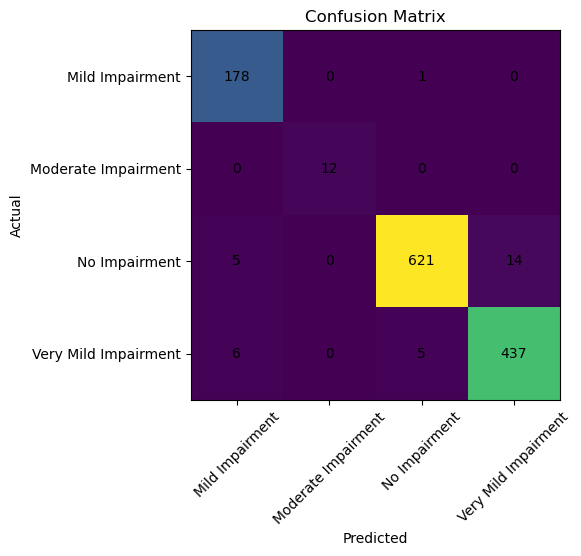

In [19]:
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

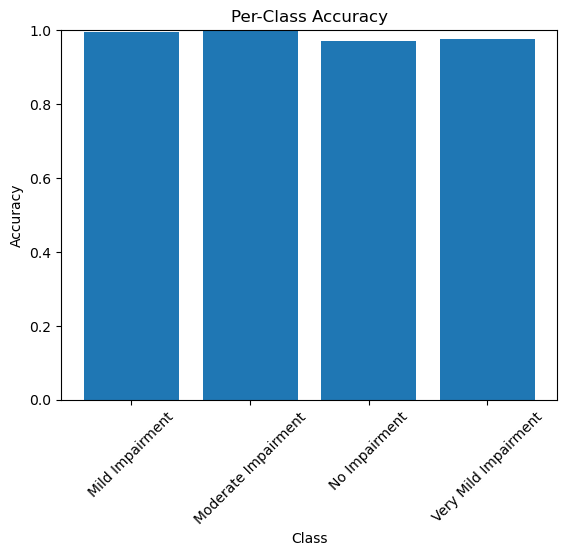

In [20]:
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

plt.figure()
plt.bar(class_names, per_class_accuracy)
plt.title("Per-Class Accuracy")
plt.xlabel("Class")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()